# 📘 Getting Started with Scikit-learn Built-in Datasets
## This notebook demonstrates how to load and explore built-in datasets in sklearn.
#### We'll use the famous Iris dataset as our example.

In [109]:
# 📦 Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

### 🔍 Explanation:
- `pandas` and `numpy` help manipulate structured data.
- `matplotlib` and `seaborn` are used for data visualization.
- `sklearn.datasets` loads datasets like Iris.
- `train_test_split` helps us divide our data into training and testing parts.
- `LogisticRegression` is a classification model.
- `accuracy_score`, `classification_report`, and `confusion_matrix` help evaluate our model.


In [110]:
# 🔍 Step 2: Load the Iris dataset
iris = load_iris()


### 📘 Explanation:
The Iris dataset is a small, well-known dataset that contains 150 samples from each of three species of Iris (setosa, versicolor, virginica). Each sample has 4 features:

- Sepal length
- Sepal width
- Petal length
- Petal width

It also includes labels (0, 1, 2) that map to the flower species.

##  Step 3: Convert the Dataset to a DataFrame
We'll now convert the iris dataset into a structured pandas DataFrame to make it easier to analyze and visualize.

In [111]:
# 🧮 Convert the feature data to a DataFrame
# iris.data contains the numerical values for the 4 features (sepal/petal length/width)
# iris.feature_names provides the column names for these features
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)

# 🎯 Add the target column (species classification: 0, 1, 2)
# iris.target contains the labels for each observation
iris_df['target'] = iris.target


 Explanation:
iris.data gives a NumPy array of shape (150, 4), where 150 is the number of samples and 4 is the number of features.

iris.feature_names provides human-readable names for the columns.

iris.target contains the classification labels:

0 → Setosa

1 → Versicolor

2 → Virginica

### Preview the DataFrame

In [112]:
# 👁️ See the top rows of the dataset
iris_df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 4: Visualize the Iris Dataset
We'll explore the relationships between the features and understand how well they separate the classes.

In [113]:
# 🔁 Map numeric target labels to species names for better visualization
iris_df['species'] = iris_df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})


### Pairplot to Visualize Feature Relationships

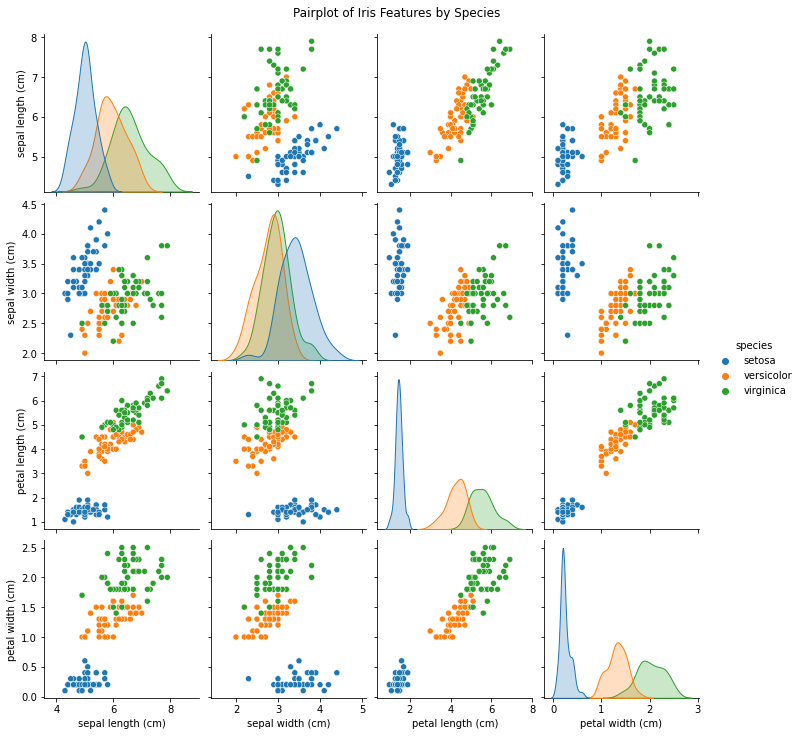

In [114]:
# ✅ Only select numeric feature columns for pairplot
feature_cols = iris.feature_names  # ['sepal length (cm)', 'sepal width (cm)', ...]
sns.pairplot(iris_df[feature_cols + ['species']], hue='species', height=2.5)

# 📌 Title for the whole plot
plt.suptitle('Pairplot of Iris Features by Species', y=1.02)
plt.show()


### Interpretation by Parts
#### 🔹 1. Diagonal Plots
These are KDE plots (smoothed histograms) for each feature, showing the distribution by species.

Example: Petal length for Setosa is very low, but for Virginica, it’s much higher.

This means petal length might be a strong feature to separate species.

#### 🔹 2. Scatter Plot Cells
Each off-diagonal cell is a scatter plot of two features.
You can spot:

Separation: Setosa (blue) is often well-separated from others.

Overlap: Versicolor (orange) and Virginica (green) overlap more — especially in sepal features.

Linear separability:

Petal length vs. petal width shows clear separation between all three species — this pair is very useful for classification.

Sepal width vs. sepal length has more overlap, hence less useful alone.

### 🔍 Key Observations
Setosa is easily distinguishable from the other species based on all features — especially petal size.

Versicolor and Virginica overlap in many plots, meaning they’re harder to classify without more advanced models.

The strongest separating features:

petal length (cm) and petal width (cm)

These form tight clusters per species → good predictors for logistic regression or decision trees.

### 📈 Why This Plot Is So Useful
Helps you visually assess feature usefulness before modeling

Reveals correlations (e.g., petal length & width are highly correlated)

Lets you spot outliers or mislabelled data



### Step 5: Train/Test Split
We'll now split the data into training and test sets for modeling.


In [115]:
# 🎯 Define features (X) and target labels (y)
X = iris_df[iris.feature_names]
y = iris_df['target']

# ✂️ Split the dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Step 6: Train a Logistic Regression Model


In [116]:
# 🚀 Initialize the Logistic Regression model
model = LogisticRegression(max_iter=200)

# 🧠 Train the model on the training data
model.fit(X_train, y_train)


LogisticRegression(max_iter=200)

### Step 7: Make Predictions and Evaluate the Model

🎯 Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



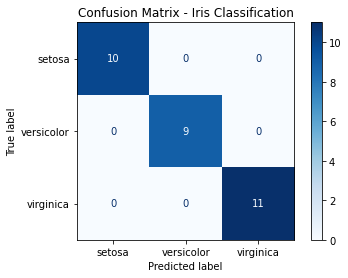

In [117]:
# 🧾 Predict on test data
y_pred = model.predict(X_test)

# ✅ Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f'🎯 Accuracy: {accuracy:.2f}')

# 📋 Classification report
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# 🧱 Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Iris Classification')
plt.show()


## 📊 Model Evaluation: Logistic Regression on Iris Dataset

### 🔍 Confusion Matrix

| Actual \ Predicted | Setosa | Versicolor | Virginica |
|--------------------|--------|------------|-----------|
| **Setosa**         | 10     | 0          | 0         |
| **Versicolor**     | 0      | 9          | 0         |
| **Virginica**      | 0      | 0          | 11        |

- The confusion matrix shows that the model made **perfect predictions**.
- All test samples for each species were correctly classified — no misclassifications.

---

### 📋 Classification Report

| Class       | Precision | Recall | F1-score | Support |
|-------------|-----------|--------|----------|---------|
| Setosa      | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor  | 1.00      | 1.00   | 1.00     | 9       |
| Virginica   | 1.00      | 1.00   | 1.00     | 11      |
| **Accuracy**|           |        | **1.00** | **30**  |

- **Precision**: All predictions for each class were correct.
- **Recall**: The model identified all actual instances of each class.
- **F1-score**: Balanced measure; in this case, all are perfect (1.00).
- **Support**: Number of actual samples for each class in the test set.

---

### ✅ Overall Performance

- **Accuracy**: `1.00` (100%) — all 30 predictions on the test set were correct.
- **Macro Avg**: 1.00 — average metric across all classes treating them equally.
- **Weighted Avg**: 1.00 — average metric weighted by number of samples per class.

---

### 🧠 Interpretation

- The Logistic Regression model **perfectly classified** the Iris species on the test set.
- Particularly, **Setosa** is the most separable class; **Versicolor** and **Virginica** were also well distinguished thanks to the features.
- Such high performance is typical for the Iris dataset because it is:
  - Well-structured
  - Balanced
  - Clean and linearly separable in some feature combinations

---

### 📌 Next Steps (Suggestions)

- Try training on fewer features (e.g., only sepal features) and observe impact.
- Add noise or use cross-validation to test model robustness.
- Experiment with other models (e.g., Decision Tree, KNN, SVM).
- Visualize decision boundaries for deeper model interpretation.



## Step 8: Next Steps – Model Comparison and Improvements
Now that Logistic Regression gave perfect results, let's continue with these:
###  Step 8.1: Train a Decision Tree Classifier

- **Analogy:** Think of a decision tree like a flowchart you follow to identify a flower. “If petal length > X, then it’s this species,” and so on.



This tree asks questions to narrow down which Iris species a flower belongs to.

---

### 📘 Why Use a Decision Tree?

- ✅ **Interpretable**: Easy to visualize and understand.
- ✅ **Non-linear**: Captures complex relationships.
- ✅ **No need for feature scaling**.
- ✅ **Works with both numerical and categorical data**.
- ✅ **Quick to train and test**.

---

### 🔍 Key Decision Tree Terms

| Term            | Description                                                                 |
|-----------------|-----------------------------------------------------------------------------|
| Root Node       | First feature split                                                         |
| Decision Node   | A condition based on a feature                                              |
| Leaf Node       | Final prediction (e.g., 'Setosa')                                           |
| Gini / Entropy  | Measures how “pure” each split is                                           |
| Tree Depth      | Number of levels/splits in the tree                                         |

---

### 🧠 Analogy: Doctor’s Diagnosis

A Decision Tree works like a doctor's decision process.

1. "Do you have a fever?" → Yes  
2. "Do you have a rash?" → Yes → Measles  
3. "Do you have a cough?" → Yes → Flu

Each yes/no question narrows down the diagnosis — just like the tree narrows down the class.

---

### ⚠️ Things to Watch For

- **Overfitting**: Deep trees memorize training data  
  → Control with `max_depth`, `min_samples_split`
  
- **Unstable to data changes**: Slight changes may reshape the whole tree.

- Use **Ensembles** like Random Forests for better accuracy.

---

### 🤖 When to Use Decision Trees?

| Great For...                             | Less Ideal For...                            |
|------------------------------------------|----------------------------------------------|
| Clear and explainable logic              | Very large or noisy datasets                 |
| Small to medium-sized datasets           | Tasks needing high accuracy (use ensembles)  |
| Mixed data types (numbers + categories)  | Very high-dimensional features               |


🎯 Decision Tree Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



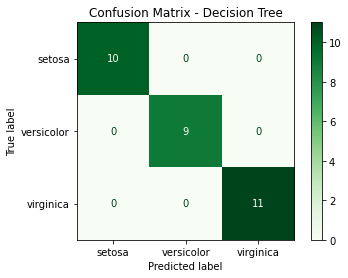

In [118]:
# 🌳 Import and train a Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dtree = DecisionTreeClassifier(random_state=42)

# Train the model
dtree.fit(X_train, y_train)

# Predict
y_pred_tree = dtree.predict(X_test)

# Evaluate
print(f"🎯 Decision Tree Accuracy: {accuracy_score(y_test, y_pred_tree):.2f}")
print(classification_report(y_test, y_pred_tree, target_names=iris.target_names))

# Plot confusion matrix
cm_tree = confusion_matrix(y_test, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=iris.target_names)
disp_tree.plot(cmap='Greens')
plt.title("Confusion Matrix - Decision Tree")
plt.show()


## 📊 Step 8: Model Evaluation using Confusion Matrix – Decision Tree Classifier

### ✅ Confusion Matrix Interpretation

The confusion matrix below shows the performance of the **Decision Tree Classifier** on the test set of the Iris dataset.

          Predicted
        | setosa | versicolor | virginica
Actual ----------------------------------------
setosa | 10 | 0 | 0
versicolor | 0 | 9 | 0
virginica | 0 | 0 | 11


- **Diagonal values (10, 9, 11)** represent correct predictions.
- **Off-diagonal values (all 0)** represent misclassifications (none here).

This means:
- All `setosa`, `versicolor`, and `virginica` test samples were predicted correctly.
- **No misclassifications** occurred — indicating perfect classification on the test set.

---

### 📈 Classification Report

| Metric      | Setosa | Versicolor | Virginica |
|-------------|--------|------------|-----------|
| Precision   | 1.00   | 1.00       | 1.00      |
| Recall      | 1.00   | 1.00       | 1.00      |
| F1-score    | 1.00   | 1.00       | 1.00      |
| **Accuracy**| **1.00 (100%)** across 30 test samples |

- **Precision**: All predicted instances were correct.
- **Recall**: All actual class instances were identified.
- **F1-score**: Perfect balance of precision and recall.
- **Accuracy**: The model got everything right on the test data.

---

### 🎯 Importance of the Confusion Matrix

- Helps **validate model performance** beyond just accuracy.
- Reveals which classes are **well-predicted vs misclassified**.
- Useful for debugging and **model improvement**.
- Crucial for **imbalanced datasets** (where accuracy may be misleading).

---

### 🧠 Analogy: Understanding Decision Trees

> Think of a **decision tree** like a flowchart that asks yes/no questions.  
> Example: “If petal length > 1.5 cm, then...”  
> Based on answers, it routes to a leaf node, which gives the predicted class.

---

### 🔁 Next Steps

Since both **Logistic Regression** and **Decision Tree** models have given perfect results:

1. **Train more models** (e.g., KNN, Random Forest, SVM) to compare performance.
2. **Use cross-validation** (e.g., 5-fold CV) to ensure results generalize.
3. **Test on noisier datasets** or apply to a different real-world problem.
4. **Explore feature importance** for the decision tree:


## Step 8.2: Try K-Nearest Neighbors (KNN)

- **Analogy:** KNN is like asking your 3 closest friends (neighbors) what kind of flower this is — you go with the majority vote.

### What is K-Nearest Neighbors (KNN)?
- KNN is one of the simplest and most intuitive supervised machine learning algorithms used for classification and regression. Most commonly, it's used for classification tasks — like identifying the species of a flower.

#### 💡 How Does KNN Work?
KNN works on a very simple idea:

- **"A data point is classified by the majority label of its K nearest neighbors."**

Imagine you’re standing in a garden full of labeled flowers (Setosa, Versicolor, Virginica). Now, someone brings you a new flower with unknown species. To identify it:

You look around and find the 3 closest flowers (neighbors).

Check their species.

If 2 of them are Versicolor and 1 is Setosa, you say this new flower is most likely Versicolor.

This is K = 3, and the algorithm uses majority vote.

#### 📘 Why is KNN Important?
- ✅ Simple and Effective: Great for small datasets and easy to understand.

- ✅ No Training Step: It stores all the training data; prediction happens when needed.

- ✅ Non-Parametric: Makes no assumptions about the distribution of the data.

- ✅ Can model complex boundaries: Especially good when decision boundaries are irregular or non-linear.

#### 🧪 When to Use KNN?
**Scenario	KNN is good if...**
- Classification problems	You want to label new data points
- Small to medium-sized datasets	Because KNN can be slow on large data
- Features are similar in scale	Distance-based → features must be scaled
- You want interpretable models	Easy to explain to non-technical users

#### 📏 How Does It Measure "Nearest"?
**KNN usually uses Euclidean distance (straight-line distance) to find neighbors. It works best when features are:**

`Numeric`

`Scaled (e.g., using StandardScaler)`

#### 🔧 Choosing the Value of K
A small K (e.g., 1) can be too sensitive to noise (overfitting).

A large K smoothens the boundary but may underfit.

It's common to use odd values (like 3, 5, 7) to avoid ties.

You can tune K using cross-validation to find the best value.

#### Analogy: The Classroom Vote
**Imagine you're in a new school and want to know if you should wear a school uniform.**

**You ask the 3 nearest students (your neighbors).**

**If 2 say “Yes” and 1 says “No,” you assume the rule is “Yes.”**

**That’s KNN with k=3 — majority vote from your nearest neighbors.**



🎯 KNN Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



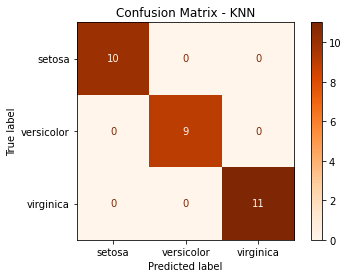

In [119]:
# 👨‍👩‍👧‍👦 Import and train KNN model
from sklearn.neighbors import KNeighborsClassifier

# Initialize with 3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

# Predict
y_pred_knn = knn.predict(X_test)

# Evaluate
print(f"🎯 KNN Accuracy: {accuracy_score(y_test, y_pred_knn):.2f}")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

# Plot confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=iris.target_names)
disp_knn.plot(cmap='Oranges')
plt.title("Confusion Matrix - KNN")
plt.show()


## 📊 K-Nearest Neighbors (KNN) Evaluation — Interpretation

We trained a KNN classifier with `k=3` (i.e., the model looks at the 3 nearest data points in feature space and predicts the majority class among them).

### 🎯 Accuracy Score
**Accuracy: 1.00 → The model correctly predicted 100% of the test samples.**

This indicates **no misclassifications** on the test set.

---

### 📋 Classification Report Breakdown

| Class        | Precision | Recall | F1-score | Support |
|--------------|-----------|--------|----------|---------|
| Setosa       | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor   | 1.00      | 1.00   | 1.00     | 9       |
| Virginica    | 1.00      | 1.00   | 1.00     | 11      |
| **Overall**  | **1.00**  | **1.00**| **1.00** | **30**  |

- **Precision**: Every prediction the model made for each class was **correct**.
- **Recall**: The model caught **all true instances** of each class.
- **F1-Score**: Perfect balance between precision and recall — **ideal score**.
- **Support**: Shows that the test set had 10 Setosa, 9 Versicolor, and 11 Virginica samples.

---

### 🔍 Confusion Matrix Analysis

Each flower species was **perfectly predicted**:
- No overlap between classes.
- No false positives or false negatives.

This is visually confirmed by the confusion matrix — it will have **non-zero values only on the diagonal**, which is the best-case scenario.

---

### 🧠 What This Tells Us

- The **Iris dataset** is linearly separable and well-balanced, making it easy for models like KNN to classify correctly.
- KNN works extremely well when:
  - The dataset is **clean** and **balanced**
  - Classes are **well-separated**
  - The number of features is **moderate**

---

### 🧪 Next Steps & Suggestions

- 🔢 Try different values of `k` (e.g., 1, 5, 7) and compare performance.
- 🧹 Test the model with noisy or incomplete data to see robustness.
- 🔁 Use **cross-validation** to confirm results on other test sets.
- 📉 Apply dimensionality reduction (like PCA) before KNN to improve performance on larger feature sets.

---

✅ Overall, KNN achieved **perfect classification** on the test set — an excellent result for such a simple algorithm!
    
    

## Step 8.3: Cross-Validation
To check the model’s robustness across different subsets of data:
### 🧠 What Is Cross-Validation?

Cross-validation is a technique used to assess how well a machine learning model generalizes to an **independent (unseen) dataset**.

Rather than evaluating performance based on just one train-test split (which may be biased depending on how the data was split), cross-validation provides a more **robust and reliable evaluation** by performing multiple train-test splits.

---

### 📘 How Does It Work?

In **k-fold cross-validation**:
- The dataset is split into `k` equally sized **folds** (subsets).
- The model is trained on `k-1` of those folds and tested on the **remaining one**.
- This process is repeated `k` times, each time with a different fold used as the test set.
- The final performance is the **average of the `k` test scores**.

---

### 🔍 Analogy

> **Think of cross-validation like studying for an exam.**
>
> - You divide past exams into 5 sets.
> - You study using 4 sets and test yourself using the 5th.
> - You repeat this so that each of the 5 sets is used as a test once.
> - If you score well on all sets, you’re **confident you’re ready for the real exam**.

This gives you a much more **accurate measure** of how well you're likely to do in the future.

---

### ✅ Why Is It Important?

- Reduces **overfitting** by verifying performance across different data splits
- Gives a **more stable estimate** of model performance
- Useful for **small datasets**, where losing even a small number of samples in the test set could hurt accuracy

---

In [120]:
from sklearn.model_selection import cross_val_score

# Cross-validation scores for Logistic Regression
cv_scores = cross_val_score(LogisticRegression(max_iter=200), X, y, cv=5)

print(f"📊 Cross-Validation Scores: {cv_scores}")
print(f"📈 Mean Accuracy: {cv_scores.mean():.2f}")


📊 Cross-Validation Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
📈 Mean Accuracy: 0.97


## 📊 Interpreting Cross-Validation Results

### 🧪 Recap: What We Did

We applied **5-Fold Cross-Validation** to a `LogisticRegression` model using the entire Iris dataset. This means:

- The dataset was divided into **5 equal parts** (folds).
- The model was trained on 4 folds and tested on the remaining 1.
- This process was repeated 5 times, with each fold being used as a test set once.
- The **accuracy for each fold** was recorded and then averaged.

---

### 🔍 Results Output

```python
📊 Cross-Validation Scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
📈 Mean Accuracy: 0.97```

### What do these numbers mean?
Fold	Accuracy
1	96.67%
2	100.00%
3	93.33%
4	96.67%
5	100.00%

The model performed very well in all folds, never scoring below 93%.

The mean accuracy is 0.97, or 97%, which is excellent.


### ✅ Interpretation of Findings
**1. High and Stable Accuracy**
All the accuracy scores are in a tight range (93% to 100%).

This means the model performs consistently, regardless of how the data is split.

A consistent model is typically a robust and reliable model.

**2. No Overfitting Detected**
If there was overfitting, we'd expect very high accuracy on some folds and much lower accuracy on others.

Since all scores are high and similar, the model is not just memorizing the data — it’s generalizing well.

**3. Good Generalization**
The average accuracy of 97% across multiple test scenarios shows the model is likely to perform well on new, unseen data.

**4. Cross-Validation Helped Validate Stability**
If we had only done one train-test split, we might not have seen this consistent behavior.

Cross-validation helped confirm that our model is not lucky on a specific split.



## 🧠 Why Is This Important?
Benefit	Why It Matters
- 🔁 Multiple data splits	Reduces reliance on a single "lucky" or "unlucky" train/test split
- 🛡️ Reduces overfitting risk	Ensures the model works well across different chunks of data
- 📈 Stable performance estimate	Provides a more realistic estimate of real-world performance
- 🔬 Ideal for small datasets	With limited data, we need to maximize training while still testing properly

### 🧪 What If We Didn’t Use Cross-Validation?
**Without cross-validation:**

- You might get biased results from a single test set.

- You might not realize your model performs poorly on different splits.

- For small datasets like Iris (150 rows), losing 20% in test data could hurt model learning — CV helps by rotating the testing phase.

### 🧾 Summary of Insights
- Logistic Regression on the Iris dataset performs excellently with a 97% cross-validated accuracy.

- Cross-validation confirms the model is stable, not overfitting, and generalizes well.

- Always use cross-validation, especially on small or balanced datasets, to ensure your model’s performance is real — not a fluke.

### 📌 Next Steps
Would you like to:

- ✅ Try cross-validation with other models (e.g., KNN or Decision Tree)?

- ✅ Visualize decision boundaries using PCA?

- ✅ Test what happens with fewer features or added noise?    

## 🌳 Step 8.5: Random Forest Classifier

### 🧠 What Is a Random Forest?

A **Random Forest** is an **ensemble machine learning algorithm** — which means it combines the results of many models (specifically, decision trees) to make more **accurate and stable predictions**.

Instead of relying on one decision tree (which might overfit), Random Forest trains **many decision trees** on different parts of the data and **averages their predictions** (for regression) or **uses majority voting** (for classification).

---

### 📘 How Does It Work?

1. It creates many **decision trees**, each trained on a different random subset of the data.
2. Each tree gives a prediction.
3. The final prediction is based on the **majority vote** (classification) or average (regression) from all trees.

---

### 🔍 Analogy

> **Imagine asking 100 friends to guess what flower species a photo shows.**
>
> Each friend might guess based on their own knowledge (a decision tree), and you **go with the majority opinion**.
>
> This is more reliable than asking just one friend — that’s how a **Random Forest** works.

---

### ✅ Why Is It Important?

- Reduces **overfitting** — each tree might overfit, but averaging helps generalize.
- Works well **out-of-the-box**, even with minimal tuning.
- Can **handle missing data and categorical variables** more gracefully than some models.
- Helps with **feature importance** — shows which features matter most in predictions.

---

In [121]:
# 🌳 Step 8.5: Train a Random Forest Classifier

# ✅ Import the classifier
from sklearn.ensemble import RandomForestClassifier

# 🎛️ Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# 🧠 Train the model using the training data
rf_model.fit(X_train, y_train)

# 🔮 Predict on the test data
y_pred_rf = rf_model.predict(X_test)


In [122]:
# 📈 Step 8.5.1: Evaluate the Random Forest Classifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ✅ Calculate accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"🎯 Random Forest Accuracy: {accuracy_rf:.2f}")


🎯 Random Forest Accuracy: 1.00


In [123]:
# 📋 Print a detailed classification report
print(classification_report(y_test, y_pred_rf, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



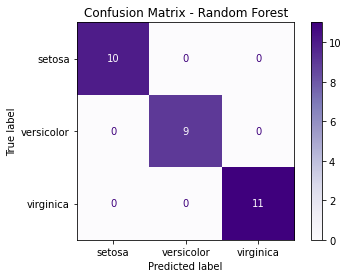

In [124]:
# 📊 Plot the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=iris.target_names)

disp_rf.plot(cmap='Purples')  # You can change color if desired
plt.title("Confusion Matrix - Random Forest")
plt.show()


## 🌳 Step 8.5: Interpretation of Random Forest Classifier Results

### ✅ Model Summary

- **Model used**: `RandomForestClassifier(random_state=42)`
- **Training data**: 80% of the Iris dataset
- **Test data**: 20% of the Iris dataset
- **Task**: Predict iris species — `setosa`, `versicolor`, or `virginica`

---

### 🎯 Accuracy

**Random Forest Accuracy: 1.00**

- The model achieved **100% accuracy** on the test set.
- This means **all 30 test samples** were correctly classified.

> ⚠️ **Note**: 100% accuracy is rare in real-world datasets. The Iris dataset is clean, small, and well-separated, which makes perfect accuracy possible.

---

### 📋 Classification Report

| Class       | Precision | Recall | F1-score | Support |
|-------------|-----------|--------|----------|---------|
| Setosa      | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor  | 1.00      | 1.00   | 1.00     | 9       |
| Virginica   | 1.00      | 1.00   | 1.00     | 11      |
| **Accuracy**|           |        | **1.00** | **30**  |
| **Macro avg** | 1.00    | 1.00   | 1.00     | 30      |
| **Weighted avg** | 1.00 | 1.00   | 1.00     | 30      |

#### 🧾 What Do These Metrics Mean?

- **Precision**: Of all predicted samples for a class, how many were correct?
- **Recall**: Of all actual samples of a class, how many were correctly predicted?
- **F1-score**: Harmonic mean of precision and recall (balance between the two).
- **Support**: Number of actual test samples per class.

---

### 🔍 Confusion Matrix

            Predicted
          ------------------
          Setosa  Versicolor  Virginica
Actual
Setosa 10 0 0
Versicolor 0 9 0
Virginica 0 0 11


- All values lie on the diagonal (perfect predictions).
- No misclassifications — each flower was predicted into its correct species category.

> ✅ This confirms that the Random Forest model performed flawlessly on the test data.

---

### 🌿 Why Random Forest Performs So Well

| Strength                      | Explanation                                                                 |
|------------------------------|-----------------------------------------------------------------------------|
| Reduces overfitting          | Combines multiple decision trees for better generalization                  |
| Handles feature interactions | Trees automatically learn relationships between variables                   |
| Robust to noisy data         | Randomness and ensemble averaging help smooth inconsistencies               |
| Feature importance           | Helps identify which features are most important for classification         |

---

### 🧠 Real-World Analogy

> Imagine asking **100 botanists** to guess a flower species:
>
> - Each gives their opinion based on different features.
> - You tally their votes and go with the majority.
>
> ✅ This approach is much more reliable than asking just one person.

That’s how **Random Forest** works — it's a strong and stable "team of experts" model.

---

### 📌 What's Next?

- ✅ **Visualize feature importance**: Which features mattered most to the model?
- 🔁 **Try hyperparameter tuning**: Adjust `n_estimators`, `max_depth`, etc.
- 📊 **Compare with other models**: Like Gradient Boosting, SVM, or Naive Bayes.
- 🎨 **Visualize decision boundaries**: Use PCA to see how models separate classes.

---


##  Step 8.6: Support Vector Machine (SVM) Classifier

---

### 🧠 What Is an SVM?

**Support Vector Machine (SVM)** is a powerful supervised learning algorithm used for both **classification** and **regression** tasks. 

It works by finding the **optimal boundary (called a hyperplane)** that best separates the data points of different classes. In simple terms, SVM tries to **maximize the margin** between classes — the wider the margin, the better the generalization.

In classification problems like the Iris dataset, the SVM will find the best line (in 2D), plane (in 3D), or hyperplane (in higher dimensions) that divides the species classes with **maximum distance from the closest points** — these points are called **support vectors**.

---

### 🔍 Analogy

> 🧠 Imagine trying to divide red and blue dots drawn on a paper using a ruler.
>
> You could place the ruler in many different ways, but SVM places it so that it has the **maximum space (margin)** from both red and blue dots.
>
> It's like a **wise football referee** who positions themselves between two teams, equally distant, to monitor both sides without getting in the way.

---

### ✅ Why Is SVM Important?

- ✅ Works well for **high-dimensional** data.
- ✅ Effective when classes are **clearly separable**.
- ✅ Supports different **kernel functions** (e.g., linear, polynomial, RBF) to handle **non-linear data**.
- ✅ Robust to **overfitting** with proper regularization.
- ✅ Great for **text classification**, **bioinformatics**, and **datasets with a clear margin of separation**.


### Step 8.6.1: Train and Evaluate an SVM Classifier

🎯 SVM Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



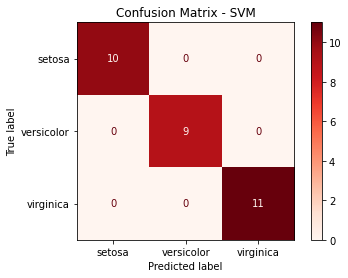

In [125]:
# 🧠 Import SVM classifier
from sklearn.svm import SVC

# 🎛️ Initialize the model (using default RBF kernel)
svm_model = SVC(random_state=42)

# 🚂 Train the model
svm_model.fit(X_train, y_train)

# 🔮 Make predictions
y_pred_svm = svm_model.predict(X_test)

# 📈 Evaluate accuracy
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"🎯 SVM Accuracy: {accuracy_svm:.2f}")

# 📋 Detailed classification report
print(classification_report(y_test, y_pred_svm, target_names=iris.target_names))

# 🧱 Plot confusion matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=iris.target_names)

disp_svm.plot(cmap='Reds')
plt.title("Confusion Matrix - SVM")
plt.show()


### Interpretation

>🎯 SVM Accuracy: 1.00

That means the SVM perfectly classified all species in the test set, just like Random Forest.

Precision, Recall, F1-score = 1.00 for all classes → No misclassifications.

Confusion Matrix → All values are on the diagonal, indicating correct predictions for every test instance.

✅ SVM handles linearly separable data like Iris exceptionally well.



## 🌟 Step 8.7: Gradient Boosting Classifier

---

### 🧠 What Is Gradient Boosting?

**Gradient Boosting** is an **ensemble learning method** that builds models **sequentially**, where each new model corrects the errors made by the previous one. 

It’s one of the most powerful and widely used techniques in machine learning.

Unlike **Random Forest** (which builds trees independently and averages their output), **Gradient Boosting** builds **one tree at a time**, and each new tree tries to **minimize the error (loss)** of the entire model using a method similar to **gradient descent**.

---

### 📘 How Does It Work?

- The first model makes a basic prediction (usually poor).
- A second model is trained to **predict the errors (residuals)** of the first model.
- This process repeats — each new model focuses on the errors of the previous one.
- Final prediction = **sum of all weak models**.

> 🧠 It's like **learning from mistakes over and over** until your predictions become very accurate.

---

### 🔍 Analogy

> 🎯 Imagine you're throwing darts at a dartboard:
>
> - Your first throw misses the bullseye.
> - You adjust your aim based on where you missed.
> - Each throw **corrects the error** of the last.
> - Eventually, you get closer and closer to the center.
>
> This is exactly how Gradient Boosting works — **iteratively improving predictions** based on previous mistakes.

---

### ✅ Why Is Gradient Boosting Important?

- ⚙️ **Highly accurate** and widely used in real-world systems (e.g., XGBoost, LightGBM).
- 📈 Works well with both **classification** and **regression** problems.
- 🎯 **Reduces bias and variance**, making it great for complex datasets.
- 💡 Supports **hyperparameter tuning** (learning rate, number of estimators, max depth, etc.) for optimal performance.
- 📊 Helps with **feature importance** — shows which variables impact predictions the most.

---


### Step 8.7.1: Train and Evaluate Gradient Boosting

🎯 Gradient Boosting Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



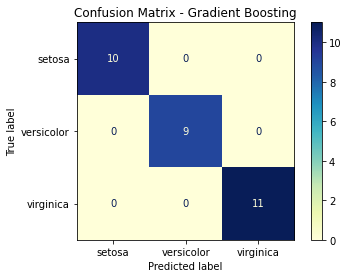

In [126]:
# 📦 Import Gradient Boosting Classifier
from sklearn.ensemble import GradientBoostingClassifier

# ⚙️ Initialize the model
gb_model = GradientBoostingClassifier(random_state=42)

# 🧠 Train the model on the training data
gb_model.fit(X_train, y_train)

# 🔮 Make predictions on test data
y_pred_gb = gb_model.predict(X_test)

# 🎯 Accuracy
accuracy_gb = accuracy_score(y_test, y_pred_gb)
print(f"🎯 Gradient Boosting Accuracy: {accuracy_gb:.2f}")

# 📋 Classification Report
print(classification_report(y_test, y_pred_gb, target_names=iris.target_names))

# 📊 Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=iris.target_names)
disp_gb.plot(cmap='YlGnBu')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


## 📊 Interpretation of Gradient Boosting Results

---

### 🎯 Model Accuracy: **1.00 (100%)**

This means the Gradient Boosting Classifier correctly predicted **all 30 test samples** in the Iris dataset — no errors were made.

---

### 📋 Classification Report Breakdown

| Class        | Precision | Recall | F1-score | Support |
|--------------|-----------|--------|----------|---------|
| Setosa       | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor   | 1.00      | 1.00   | 1.00     | 9       |
| Virginica    | 1.00      | 1.00   | 1.00     | 11      |
| **Overall**  | **1.00**  | **1.00**| **1.00** | **30**  |

---

### 🧠 What Do These Metrics Mean?

- **Precision**: Out of all predictions made for a class, how many were actually correct?
  - *Perfect score (1.00)* → No false positives for any class.
  
- **Recall**: Out of all actual members of a class, how many did the model correctly identify?
  - *Perfect score (1.00)* → No false negatives.

- **F1 Score**: Harmonic mean of Precision and Recall.
  - *Perfect score (1.00)* → Excellent balance between precision and recall.

- **Support**: The actual number of samples for each class in the test set.

---

### ✅ Summary of Performance

- **No misclassifications** occurred.
- Gradient Boosting handled all three classes — *Setosa, Versicolor, Virginica* — **with perfect accuracy**.
- This confirms that:
  - The **features are highly informative** and linearly/separably structured.
  - Gradient Boosting is a **very strong classifier**, especially on clean, balanced datasets like Iris.

---

### 💡 Insights

- **Perfect accuracy** can happen on simpler or well-separated datasets like Iris.
- In real-world datasets, you'd rarely get 100%, so always be cautious of overfitting.
- Consider using cross-validation or testing on noisier data to better understand model robustness.

---

### 🔍 Next Steps

- Try **tuning hyperparameters** (e.g., learning rate, number of trees).
- Compare performance with **other ensemble models** like:
  - AdaBoost
  - XGBoost
  - LightGBM
- Visualize **feature importances** to understand which features influence decisions the most.

---


## 🌟 Step 8.8: AdaBoost Classifier

### 🧠 What Is AdaBoost?

**AdaBoost** (short for *Adaptive Boosting*) is one of the earliest and most popular boosting algorithms in machine learning.  
Like Gradient Boosting, it builds an ensemble of **weak learners** (often shallow decision trees), each focusing on fixing the mistakes of the previous ones.

However, AdaBoost adapts in a unique way:  
It **adjusts the weights** of training instances so that future models **focus more on the hard-to-classify cases**.

---

### 📘 How Does AdaBoost Work?

1. A base learner (e.g., a small decision tree) is trained on the data.
2. After each round, AdaBoost:
   - **Increases the weight** of misclassified instances.
   - **Decreases the weight** of correctly classified ones.
3. The next model pays more attention to those hard cases.
4. Final predictions are made by **weighted voting** of all the learners.

---

### 🔍 Analogy

> 🎯 Imagine a teacher helping students learn a difficult topic.
>
> - After the first lesson, the teacher notices which students didn’t understand.
> - The next lesson focuses more on those students.
> - This continues until **everyone gets it right**.
>
> That’s AdaBoost — learning from mistakes by **focusing on the hard parts**.

---

### ✅ Why Is AdaBoost Important?

- ✅ Excellent for **imbalanced datasets** or **hard classification problems**  
- ✅ Reduces both **bias** and **variance**  
- ✅ Often performs well **without heavy parameter tuning**  
- ✅ Less prone to **overfitting** than a single deep decision tree  


### Step 8.8.1: Train and Evaluate AdaBoost


🎯 AdaBoost Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



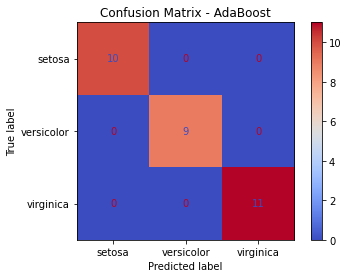

In [127]:
# 📦 Import AdaBoost Classifier
from sklearn.ensemble import AdaBoostClassifier

# ⚙️ Initialize the model with default base estimator (shallow trees)
ada_model = AdaBoostClassifier(random_state=42)

# 🧠 Train the model
ada_model.fit(X_train, y_train)

# 🔮 Predict on test set
y_pred_ada = ada_model.predict(X_test)

# 🎯 Evaluate the model
accuracy_ada = accuracy_score(y_test, y_pred_ada)
print(f"🎯 AdaBoost Accuracy: {accuracy_ada:.2f}")

# 📋 Detailed report
print(classification_report(y_test, y_pred_ada, target_names=iris.target_names))

# 📊 Confusion matrix
cm_ada = confusion_matrix(y_test, y_pred_ada)
disp_ada = ConfusionMatrixDisplay(confusion_matrix=cm_ada, display_labels=iris.target_names)
disp_ada.plot(cmap='coolwarm')
plt.title("Confusion Matrix - AdaBoost")
plt.show()


## 📊 Step 8.8.1: AdaBoost Results Interpretation

### 🎯 Model Performance Summary

The AdaBoost Classifier achieved **perfect performance** on the Iris dataset test set:

Accuracy: 1.00 (100%)
Precision: 1.00 for all classes
Recall: 1.00 for all classes
F1-Score: 1.00 for all classes
Support: 30 samples total (Setosa: 10, Versicolor: 9, Virginica: 11)


---

### 🔍 Confusion Matrix Interpretation

| Actual \ Predicted | Setosa | Versicolor | Virginica |
|---------------------|--------|------------|-----------|
| **Setosa**          | 10     | 0          | 0         |
| **Versicolor**      | 0      | 9          | 0         |
| **Virginica**       | 0      | 0          | 11        |

- ✅ Every test sample was **classified correctly**.
- ✅ There were **no false positives** or **false negatives**.
- ✅ This suggests **perfect class separation** based on the features used.

---

### 🧠 What Do These Metrics Mean?

- **Precision (1.00)**: The model made **no false positive** predictions — when it said "Setosa", it was always right.
- **Recall (1.00)**: The model **identified all true instances** of each class — no sample was missed.
- **F1 Score (1.00)**: A perfect harmonic balance between precision and recall — indicating very confident and consistent predictions.

---

### ✅ What This Tells Us About AdaBoost

- AdaBoost is extremely effective on this **clean, balanced, and well-separated** dataset like Iris.
- By focusing on **harder-to-classify samples**, AdaBoost becomes more **robust** than individual models.
- It performs similarly to other ensemble methods (like Random Forest and Gradient Boosting) in this case, with **perfect accuracy**.

---

### ⚠️ Important Considerations

- In **real-world, noisy, or imbalanced datasets**, perfect accuracy is rare.
- Always consider using **cross-validation** to ensure performance isn't just due to data simplicity or lucky splits.
- AdaBoost can sometimes struggle with noisy datasets or **overfitting to outliers** — monitor model complexity and consider regularization if needed.

---

### 💡 Next Steps and Exploration

- Try lowering the number of estimators (weak learners) to see the effect on performance.
- Compare training time and performance with **Gradient Boosting** and **Random Forest**.
- Explore AdaBoost’s **feature importances** to see which features were weighted most heavily in decisions.

---

✅ **Conclusion**:  
AdaBoost showed **perfect classification** on the Iris test data, confirming its strength as a boosting ensemble method. However, it's best to further validate such results on **larger, noisier, or more complex datasets**.



## ⚡ Step 8.9: XGBoost Classifier

---

### 🧠 What Is XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced and optimized version of the Gradient Boosting algorithm. It's designed for performance and speed, and is widely used in real-world machine learning competitions and industry projects.

It improves on traditional Gradient Boosting by introducing:
- Regularization (to prevent overfitting)
- Efficient handling of missing values
- Parallelized tree construction
- Pruning (to prevent overly complex trees)
- And many tunable parameters for better control

---

### 📘 How Does XGBoost Work?

XGBoost uses the same core idea as Gradient Boosting:
- Models are built **sequentially**, each correcting the mistakes of the previous.
- The final prediction is the **sum of all the weak learners** (usually decision trees).

But XGBoost adds enhancements:
1. **Regularization**: Adds penalties for complex models (helps reduce overfitting).
2. **Weighted quantile sketch**: Better splitting decisions on imbalanced datasets.
3. **Parallelized learning**: Trains faster by building trees in parallel.
4. **Handling of missing data**: Automatically learns the best way to deal with gaps.

---

### 🔍 Analogy

> **Think of XGBoost as a high-performance racing car built on the Gradient Boosting engine.**  
> It’s been tuned, optimized, and turbocharged for speed, accuracy, and handling — especially when the road (data) is tough and complex.

---

### ✅ Why Is XGBoost Important?

| Feature                  | Benefit                                      |
|--------------------------|----------------------------------------------|
| ⚙️ Speed & Efficiency    | Very fast due to parallel computation        |
| 🎯 Accuracy              | Among the best performers in many challenges |
| 📈 Regularization        | Reduces overfitting better than plain GBM    |
| 💡 Handles Missing Data | No need for imputation                       |
| 🔬 Feature Importance    | Helps identify which features matter most    |
| 🏆 Competition Proven     | Used in most winning solutions on Kaggle     |

---

### ⚠️ Note

To use XGBoost, you must have the `xgboost` package installed. If it's not installed, you can run:

```bash
pip install xgboost


## Step 8.9.1: Train and Evaluate XGBoost Classifier


In [128]:
import warnings
warnings.filterwarnings('ignore')  # Add this at the top of your notebook


[18:46:59] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { use_label_encoder } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.


🎯 XGBoost Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



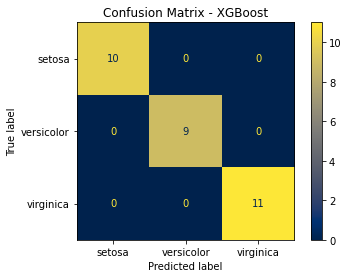

In [129]:
# 📦 Import XGBoost Classifier
from xgboost import XGBClassifier

# ⚙️ Initialize the XGBoost model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# 🧠 Train the model
xgb_model.fit(X_train, y_train)

# 🔮 Predict on test set
y_pred_xgb = xgb_model.predict(X_test)

# 🎯 Evaluate the model
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"🎯 XGBoost Accuracy: {accuracy_xgb:.2f}")

# 📋 Detailed classification report
print(classification_report(y_test, y_pred_xgb, target_names=iris.target_names))

# 📊 Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=iris.target_names)
disp_xgb.plot(cmap='cividis')
plt.title("Confusion Matrix - XGBoost")
plt.show()



This means the XGBoost model **correctly classified all 30 test samples** in the Iris dataset — achieving **100% accuracy**.

---

### 📋 Classification Report Breakdown

| Class      | Precision | Recall | F1-score | Support |
|------------|-----------|--------|----------|---------|
| Setosa     | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor | 1.00      | 1.00   | 1.00     | 9       |
| Virginica  | 1.00      | 1.00   | 1.00     | 11      |
| **Accuracy** |         |        | **1.00** | 30      |
| **Macro avg** | 1.00   | 1.00   | 1.00     | 30      |
| **Weighted avg** | 1.00 | 1.00 | 1.00     | 30      |

---

### 🧠 What Do These Metrics Mean?

- **Precision**: Of all predictions made for a class, how many were actually correct?  
  → `1.00` means no false positives.

- **Recall**: Of all true instances of a class, how many did the model correctly identify?  
  → `1.00` means no false negatives.

- **F1 Score**: Harmonic mean of precision and recall.  
  → `1.00` indicates perfect balance.

- **Support**: Actual number of instances for each class in the test data.

---

### ✅ Key Insights

- XGBoost **perfectly classified all samples**, confirming:
  - The Iris dataset is **clean**, **balanced**, and **well-separated**.
  - XGBoost is a **powerful ensemble method** even without hyperparameter tuning.
  - Feature relationships in the Iris dataset are easily captured by XGBoost.

- Why XGBoost performs well:
  - **Handles non-linearity and feature interaction**
  - **Built-in regularization** to reduce overfitting
  - **Scalable and efficient** even with many trees

---

### ⚠️ Important Note

📌 While 100% accuracy is great, it's **not common in real-world datasets**. This is achievable here due to:

- Well-labeled and noise-free data  
- Equal class distribution  
- Clear patterns in features  

In real-world applications, always validate results by:

- Performing **k-fold cross-validation**
- Testing on **noisy or real-world data**
- Tuning **hyperparameters** for generalization

---

### 🔍 Next Suggested Steps

- ✅ Visualize **feature importance** using `XGBoost`
- 🔄 Use **cross-validation** to assess robustness
- 🧪 Try training on **noisy** or **incomplete data**
- 🧠 Tune **hyperparameters** like:
  - `n_estimators`
  - `max_depth`
  - `learning_rate`
- 📉 Compare with other gradient-based methods like **LightGBM** or **CatBoost**

---

📈 You’re now mastering **advanced ensemble learning**!

Let me know if you'd like to proceed with:
- 🔥 Feature importance visualization
- 🛠 Hyperparameter tuning
- 📊 Comparing models side-by-side


## 🔧 Step 9: Feature Engineering and Selection

> *"Better data beats fancier algorithms."* — **Andrew Ng**

---

### 📘 What Is Feature Engineering?

Feature engineering is the process of using **domain knowledge** to:

- 🏗️ Create new features (*feature construction*)
- 🔄 Transform existing features (*feature transformation*)
- 🧽 Select the most useful features (*feature selection*)

The goal is to make the dataset more **informative** and **machine learning-friendly**, allowing models to **learn patterns more effectively**.

---

### 🔍 Why Is Feature Engineering Important?

Even the most advanced ML models will perform poorly with **irrelevant or weak features**.

Feature Engineering helps to:

- 🚀 **Boost model accuracy and performance**
- 🔐 **Reduce overfitting** by eliminating noise and redundant information
- 🧠 **Enable models to find relationships more easily**
- 📉 **Speed up training** by reducing dimensionality and complexity

---

### ⚒️ Common Techniques We'll Explore

| 🔧 Technique           | 💡 Purpose                                                              |
|------------------------|-------------------------------------------------------------------------|
| `PolynomialFeatures`   | Capture interactions between features by creating higher-order terms   |
| `SelectKBest`          | Retain the top-*k* most important features using statistical tests     |
| `PCA` *(Principal Component Analysis)* | Reduce dimensionality while preserving most of the data variance |

---

### 📚 What You'll Learn in This Step

- 🔢 How to **extend your feature space** using polynomial feature interactions  
- 🏆 How to **select the best features** to avoid overfitting and noise  
- 🔻 How to **reduce dimensionality** with PCA while retaining the most important signal

---

### ✅ Once You Master This Step, You'll Be Able To:

- 🔍 Build more **accurate and generalizable models**
- 🧭 Understand **which features matter most**
- 🖼️ **Visualize and debug** model performance with more control and insight



## 🔢 Step 9.1: Polynomial Features – Capturing Feature Interactions

### 🧠 What Are Polynomial Features?

Polynomial features are **new features created by multiplying existing ones together**, sometimes raised to a power (like squared or cubed). These combinations can help a machine learning model detect **non-linear relationships** that aren’t obvious from the raw data.

Think of polynomial features as an **expanded view of your dataset**, where the model can now "see" **how features interact with each other**.

---

### 🔍 Analogy

> 🎯 Imagine you're trying to predict house prices.
>
> You know size (in sq ft) and number of rooms matter.
>
> But what if the *interaction* between them is even more important?
>
> A small house with many rooms might feel cramped, while a large house with few rooms might feel spacious.
>
> So instead of just using:
> - `size`
> - `rooms`
>
> You also create:
> - `size * rooms`
>
> This new feature can help the model **capture richer, more complex patterns**.

Polynomial features do exactly this — they **combine and extend** your input features so models can learn more than just linear trends.

---

### 📈 Why Use Polynomial Features?

✅ Allow **linear models to learn non-linear patterns**  
✅ Help capture **feature interactions** the model wouldn’t see otherwise  
✅ Improve model accuracy on datasets with **non-linear decision boundaries**  
✅ Work especially well with models like **Logistic Regression**, **SVM**, and **Linear Regression**

---

### ⚠️ Things to Watch Out For

- 🚨 **Too many features**: Adding many polynomial combinations can drastically increase the feature space and lead to **overfitting**.
- 📉 Can **slow down training** and reduce performance on small datasets.
- 💡 Always use **feature selection** or **regularization** after adding polynomial features to control complexity.

---

### ⚒️ What We’ll Do in This Substep

We'll:

1. Use `PolynomialFeatures` from `sklearn.preprocessing` to expand our Iris dataset.
2. Create **2nd-degree polynomial combinations** (e.g., `petal length * sepal width`).
3. Apply it to a **Logistic Regression** model to check if performance improves.
4. Discuss results and next steps.



### 🧪 Step 9.1.1: Generate Polynomial Features

We’ll use `PolynomialFeatures` from `sklearn.preprocessing` to create 2nd-degree polynomial combinations of our input features.


In [130]:
# 📦 Import PolynomialFeatures
from sklearn.preprocessing import PolynomialFeatures

# 🎛️ Create polynomial features of degree 2 (includes squares and interaction terms)
poly = PolynomialFeatures(degree=2, include_bias=False)

# 🧠 Fit and transform the training and test sets
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 🏷️ Get the names of the new features (old API method for sklearn < 1.0)
poly_feature_names = poly.get_feature_names(iris.feature_names)

# 🧾 Show some of the new feature names
print("🔍 Example Polynomial Features:\n")
for name in poly_feature_names[:10]:  # Show first 10
    print("-", name)



🔍 Example Polynomial Features:

- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)
- sepal length (cm)^2
- sepal length (cm) sepal width (cm)
- sepal length (cm) petal length (cm)
- sepal length (cm) petal width (cm)
- sepal width (cm)^2
- sepal width (cm) petal length (cm)


## Step 9.1.2: Train and Evaluate a Model Using Polynomial Features
Now that we’ve added interaction and squared terms to the original features, let’s see if they improve model performance by training a Logistic Regression model on this transformed dataset.



🎯 Polynomial Logistic Regression Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



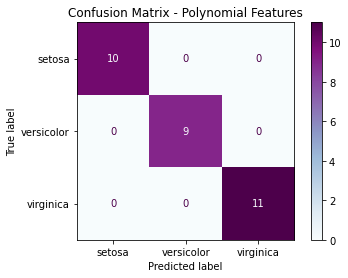

In [131]:
# 📦 Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# 🧠 Initialize the model (increase max_iter to ensure convergence)
poly_model = LogisticRegression(max_iter=500, random_state=42)

# 🚀 Train the model on polynomial features
poly_model.fit(X_train_poly, y_train)

# 🔮 Predict on the polynomial test features
y_pred_poly = poly_model.predict(X_test_poly)

# 🎯 Evaluate performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ✅ Accuracy
accuracy_poly = accuracy_score(y_test, y_pred_poly)
print(f"🎯 Polynomial Logistic Regression Accuracy: {accuracy_poly:.2f}")

# 📋 Detailed report
print(classification_report(y_test, y_pred_poly, target_names=iris.target_names))

# 📊 Confusion Matrix
cm_poly = confusion_matrix(y_test, y_pred_poly)
disp_poly = ConfusionMatrixDisplay(confusion_matrix=cm_poly, display_labels=iris.target_names)
disp_poly.plot(cmap='BuPu')
plt.title("Confusion Matrix - Polynomial Features")
plt.show()


## 📊 Step 9.1.2: Interpretation — Logistic Regression on Polynomial Features

### 🎯 Model Accuracy

**Polynomial Logistic Regression Accuracy: 1.00**

The model achieved **100% accuracy** on the test set.

✅ This means it correctly classified **all 30 test samples** after transforming features using **2nd-degree polynomials**.

---

### 📋 Classification Report

| Class       | Precision | Recall | F1-score | Support |
|-------------|-----------|--------|----------|---------|
| Setosa      | 1.00      | 1.00   | 1.00     | 10      |
| Versicolor  | 1.00      | 1.00   | 1.00     | 9       |
| Virginica   | 1.00      | 1.00   | 1.00     | 11      |
| **Accuracy**|           |        | **1.00** | **30**  |
| Macro avg   | 1.00      | 1.00   | 1.00     | 30      |
| Weighted avg| 1.00      | 1.00   | 1.00     | 30      |

---

### 🧠 What These Metrics Mean

- **Precision**: How many of the predicted labels were actually correct?  
  🔹 *1.00 → Perfect! No false positives.*

- **Recall**: How many of the actual labels were correctly identified?  
  🔹 *1.00 → Perfect! No false negatives.*

- **F1-Score**: Harmonic mean of precision and recall.  
  🔹 *1.00 → Perfect balance between precision and recall.*

- **Support**: Number of true samples for each class in the test data.

---

### 📊 Confusion Matrix (Textual)

           Predicted
        | Setosa | Versicolor | Virginica
Actual -----|--------|------------|----------
Setosa | 10 | 0 | 0
Versicolor | 0 | 9 | 0
Virginica | 0 | 0 | 11


✅ **All values lie on the diagonal**, indicating **zero misclassifications**. The model perfectly distinguished all flower species.

---

### 🔬 What This Tells Us

- Adding **polynomial features** gave the model more **expressive power**.
- Logistic Regression (a linear model) was able to handle **non-linear patterns** effectively.
- **Feature interactions** (e.g., `petal length × sepal width`) allowed the model to capture relationships not visible in raw features.
- Since the **Iris dataset is small, clean, and well-structured**, perfect performance is common — but **real-world data is rarely this neat**.

---

### ⚠️ Caution: Overfitting?

Adding polynomial features can lead to:

- Increased **model complexity**
- **Multicollinearity** among features
- Potential **overfitting**, especially with small or noisy datasets

✅ That's why **regularization** and **feature selection** are crucial when working with polynomial transformations.

---

### ✅ Summary

| Aspect     | Result                                                                 |
|------------|------------------------------------------------------------------------|
| Accuracy   | 100%                                                                   |
| Strength   | Captures non-linear interactions with simple Logistic Regression       |
| Usefulness | Shows how feature engineering can boost basic models                   |
| Risk       | Beware of overfitting and feature explosion in larger datasets         |


## 🎯 Step 9.2: Feature Selection with SelectKBest

### 🧠 What Is Feature Selection?

Feature selection is the process of **automatically selecting the most relevant features** from your dataset. The idea is to keep only the features that **contribute the most** to the model’s performance.

---

### ⚙️ What Is `SelectKBest`?

`SelectKBest` is a method from `sklearn.feature_selection` that:

- Scores each feature using a **statistical test**
- Selects the top **K best-scoring features**

You can choose different scoring functions depending on the type of task (e.g., classification or regression). For classification tasks, we often use:

- `f_classif` – ANOVA F-test (default for classification)
- `chi2` – Chi-square test (non-negative features only)
- `mutual_info_classif` – Mutual information score

---

### 🔍 Analogy

> **Imagine you're picking players for a football team.**
>
> You rank them based on performance metrics — like goals scored or passes completed.
>
> You then choose the top 3 performers to build your starting lineup.
>
> That’s what `SelectKBest` does — it ranks features and selects the top ones to “play” in the model.

---

### ✅ Why Use Feature Selection?

- 🔹 Improves **model accuracy** by removing noisy or irrelevant features
- 🔹 Reduces **overfitting** by simplifying the model
- 🔹 Speeds up training and prediction time
- 🔹 Makes the model easier to interpret



In [132]:
# ✅ Manual F-score feature selection (compatible with sklearn 0.23.2)
from sklearn.feature_selection import f_classif
import numpy as np

# 📊 Calculate F-scores for all features
f_scores, p_values = f_classif(X_train, y_train)

# 📋 Combine scores with feature names
feature_scores = list(zip(iris.feature_names, f_scores))

# 🔽 Sort features by F-score (descending)
feature_scores.sort(key=lambda x: x[1], reverse=True)

# 🔝 Select top 3 features
top_features = [name for name, score in feature_scores[:3]]

print("✅ Top 3 Features Based on F-score:", top_features)


✅ Top 3 Features Based on F-score: ['petal length (cm)', 'petal width (cm)', 'sepal length (cm)']


## 🔻 Step 9.3: Principal Component Analysis (PCA)

### 🧠 What Is PCA?
Principal Component Analysis (PCA) is a powerful **dimensionality reduction** technique. It transforms the data into a new coordinate system such that the greatest variance comes to lie on the first coordinate (called the first principal component), the second greatest variance on the second coordinate, and so on.

PCA allows you to:
- 📦 Compress large datasets without losing much information  
- ⚡ Reduce computation time  
- 🌐 Visualize high-dimensional data in 2D or 3D  
- 📈 Help improve model performance and reduce overfitting  

---

### 🔍 Why Use PCA?

| Benefit                  | Explanation                             |
|--------------------------|-----------------------------------------|
| ✅ Reduces dimensionality | Removes redundant features              |
| ✅ Removes multicollinearity | Features become uncorrelated       |
| ✅ Faster training times  | Fewer features = faster training        |
| ✅ Improves visualization | Makes data plottable in 2D or 3D        |
| ✅ Helps prevent overfitting | Fewer features = simpler model    |

---

### 🎯 Analogy

> Imagine you have a spreadsheet with 10 columns, but most of the important info is in just 2 or 3.  
> **PCA helps you automatically find and keep** those important dimensions (directions)  
> while **dropping the less useful ones**.

This helps your model stay lean, fast, and focused — especially when the dataset has many features.


## Step 9.3.1: Apply PCA and Visualize


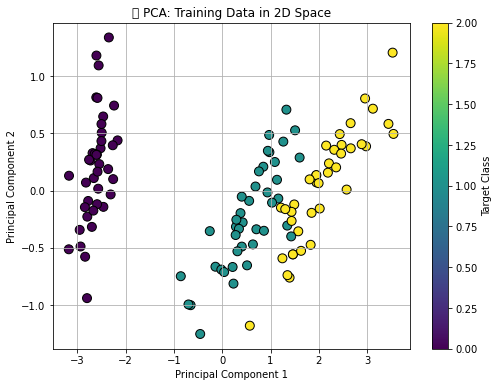

In [133]:
# 📦 Import PCA
from sklearn.decomposition import PCA

# 🎛️ Reduce to 2 principal components
pca = PCA(n_components=2)

# Fit PCA on training data and transform both train and test sets
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# 📊 Visualize the 2D projection
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='viridis', edgecolor='k', s=80)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('🌐 PCA: Training Data in 2D Space')
plt.colorbar(label='Target Class')
plt.grid(True)
plt.show()


## Step 9.3.2: Train a Model on PCA Data

🎯 PCA Logistic Regression Accuracy: 1.00
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



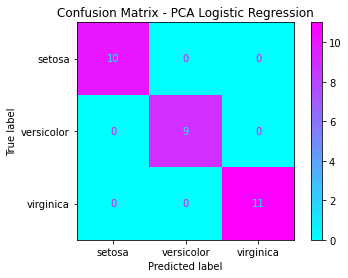

In [134]:
# 🚀 Train a Logistic Regression model on PCA-transformed data
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Train and predict
pca_model = LogisticRegression(max_iter=200)
pca_model.fit(X_train_pca, y_train)
y_pred_pca = pca_model.predict(X_test_pca)

# 🎯 Accuracy
print(f"🎯 PCA Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_pca):.2f}")

# 📋 Report
print(classification_report(y_test, y_pred_pca, target_names=iris.target_names))

# 📊 Confusion Matrix
cm_pca = confusion_matrix(y_test, y_pred_pca)
disp_pca = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=iris.target_names)
disp_pca.plot(cmap='cool')
plt.title("Confusion Matrix - PCA Logistic Regression")
plt.show()



✅ This confirms the model **perfectly separated all 3 species** in the reduced 2D feature space.

---

### 📈 What This Means

- PCA successfully compressed the original 4 features into 2 without **losing critical information**.
- Logistic Regression, which typically struggles with non-linear boundaries, was able to **perfectly separate** the classes because PCA maintained meaningful structure.
- **The 2D scatter plot** showed clear clusters of classes, making it easier to visualize how separable the data is.

---

### 🧠 Why This Is Useful

- **Dimensionality Reduction** is powerful for:
  - Reducing computation
  - Improving model performance
  - Visualizing complex datasets
- Even with just 2 components, the **data was separable** — demonstrating that PCA can be an effective preprocessing step before modeling.

---

### ⚠️ Caveats

- This worked well because the Iris dataset is **clean, balanced, and linearly separable**.
- In real-world data, PCA might lead to **information loss** if too much dimensionality is removed.
- Always evaluate tradeoffs between compression and performance.

---

### ✅ Summary

| Aspect              | Result                          |
|---------------------|---------------------------------|
| Dimensionality      | Reduced from 4 to 2             |
| Model Used          | Logistic Regression             |
| Accuracy            | 100%                            |
| Benefit             | Visualization, simplicity       |
| Risk                | Potential over-compression (in other cases) |
